# Практическая работа 3. Keras

IMDB и Keras.


## Прямое кодирование

Прямое кодирование (`one-hot encoding`) — наиболее используемый и простой способ преобразования токенов в векторы. Вы уже видели его в действии в первых примерах с наборами данных IMDB и Reuters. Он заключается в присваивании каждому слову уникального целочисленного индекса `i` с последующим его преобразованием в бинарный вектор размера `N` (размер словаря); все элементы этого вектора содержат нули, кроме `i`-го элемента, которому присваивается `1`.

Конечно, прямое кодирование можно выполнить и на уровне символов.


In [1]:
from __future__ import annotations

import os
import random
import shutil
import ssl
import string
import tarfile
import urllib.request
import zipfile
from pathlib import Path

PRACTICE_DIR = Path.cwd()

CACHE_DIR = PRACTICE_DIR / ".cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(CACHE_DIR / "matplotlib")
os.environ["IPYTHONDIR"] = str(CACHE_DIR / "ipython")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

DATA_DIR = PRACTICE_DIR / ".data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
os.environ["KERAS_HOME"] = str(DATA_DIR / "keras_home")

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import Dense, Embedding, Flatten, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

IMDB_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
GLOVE_URL = "https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip"

RAW_IMDB_ARCHIVE = DATA_DIR / "aclImdb_v1.tar.gz"
RAW_IMDB_DIR = DATA_DIR / "aclImdb"
GLOVE_ARCHIVE = DATA_DIR / "glove.6B.zip"
GLOVE_DIR = DATA_DIR / "glove.6B"
MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
np.set_printoptions(edgeitems=5, linewidth=120)


In [2]:
samples = ["The cat sat on the mat.", "The dog ate my homework."]

token_index = {}
for sample in samples:
    for word in sample.split():
        if word not in token_index:
            token_index[word] = len(token_index) + 1

max_length = 10
results = np.zeros(shape=(len(samples), max_length, max(token_index.values()) + 1))

for i, sample in enumerate(samples):
    for j, word in list(enumerate(sample.split()))[:max_length]:
        index = token_index.get(word)
        results[i, j, index] = 1.0

print("Индекс токенов:", token_index)
print("Форма результата:", results.shape)


Индекс токенов: {'The': 1, 'cat': 2, 'sat': 3, 'on': 4, 'the': 5, 'mat.': 6, 'dog': 7, 'ate': 8, 'my': 9, 'homework.': 10}
Форма результата: (2, 10, 11)


## Прямое кодирование на уровне символов


In [3]:
samples = ["The cat sat on the mat.", "The dog ate my homework."]

characters = string.printable
token_index = dict(zip(characters, range(1, len(characters) + 1)))

max_length = 50
results = np.zeros((len(samples), max_length, len(token_index) + 1))

for i, sample in enumerate(samples):
    for j, character in enumerate(sample[:max_length]):
        index = token_index.get(character)
        results[i, j, index] = 1.0

print("Количество символов:", len(token_index))
print("Форма результата:", results.shape)


Количество символов: 100
Форма результата: (2, 50, 101)


Следует отметить, что во фреймворке Keras имеются встроенные утилиты для прямого кодирования простых текстовых данных на уровне слов и символов. Воспользуйтесь этими утилитами, поскольку они обладают рядом важных свойств, таких как удаление из строк специальных символов и возможность принимать в расчет только `N` слов, наиболее часто встречающихся в наборе данных (типичное ограничение, помогающее избежать создания слишком обширного пространства входных векторов).


## Использование Keras для прямого кодирования слов


In [4]:
samples = ["The cat sat on the mat.", "The dog ate my homework."]

tokenizer = Tokenizer(num_words=1000)
tokenizer.fit_on_texts(samples)

sequences = tokenizer.texts_to_sequences(samples)
one_hot_results = tokenizer.texts_to_matrix(samples, mode="binary")
word_index = tokenizer.word_index

print("Последовательности:", sequences)
print("Форма матрицы:", one_hot_results.shape)
print("Found %s unique tokens." % len(word_index))


Последовательности: [[1, 2, 3, 4, 1, 5], [1, 6, 7, 8, 9]]
Форма матрицы: (2, 1000)
Found 9 unique tokens.


Прием прямого кодирования имеет разновидность — так называемое прямое хеширование признаков (`one-hot hashing trick`), которое можно использовать, когда словарь содержит слишком большое количество токенов, чтобы его можно было использовать явно. Вместо явного присваивания индекса каждому слову и сохранения ссылок на эти индексы в словаре можно хешировать слова в векторы фиксированного размера. Обычно для этого используются очень легковесные функции хеширования. Главное достоинство этого метода — отсутствие необходимости хранить индексы слов, что позволяет сэкономить память и кодировать данные по мере необходимости (векторы токенов можно генерировать сразу же, по мере их обхода, до просмотра всех имеющихся данных). Единственный недостаток — этот метод восприимчив к хеш-коллизиям: два разных слова могут получить одинаковые хеш-значения, и впоследствии любая модель машинного обучения не сможет различить эти слова. Вероятность хеш-коллизий снижается, когда размер пространства хеширования намного больше общего количества уникальных токенов, подвергаемых хешированию.


## Прямое кодирование на уровне слов с использованием хеширования


In [5]:
samples = ["The cat sat on the mat.", "The dog ate my homework."]

dimensionality = 1000
max_length = 10
results = np.zeros((len(samples), max_length, dimensionality))

for i, sample in enumerate(samples):
    for j, word in list(enumerate(sample.split()))[:max_length]:
        index = abs(hash(word)) % dimensionality
        results[i, j, index] = 1.0

print("Форма результата:", results.shape)


Форма результата: (2, 10, 1000)


## Векторное представление слов

Другим популярным и мощным способом связывания вектора со словом является использование плотных векторов слов, или векторного представления слов (word embeddings). В отличие от векторов, полученных прямым кодированием, — бинарных, разреженных (почти полностью состоящих из нулей) и с большой размерностью (их размерность совпадает с количеством слов в словаре) — векторные представления слов являются малоразмерными векторами вещественных чисел (то есть плотными векторами, в противоположность разреженным. В отличие от векторов, полученных прямым кодированием, векторные представления слов конструируются из данных. При работе с огромными словарями размерность векторов слов нередко может достигать 256, 512 или 1024. С другой стороны, прямое кодирование слов обычно влечет за собой создание векторов с числом измерений 20 000 или больше (при использовании словаря с 20 000 токенов, как в данном случае). Иначе говоря, векторное представление слов позволяет уместить больший объем информации в меньшее число измерений.

Получить векторные представления слов можно двумя способами:

• Конструировать векторные представления в процессе решения основной задачи (такой, как классификация документа или определение эмоциональной окраски). В этом случае изначально создаются случайные векторы слов, которые затем постепенно конструируются (обучаются), как это происходит с весами нейронной сети.
• Загрузить в модель векторные представления, полученные с использованием другой задачи машинного обучения, отличной от решаемой. Такие представления называют предварительно обученными векторными представлениями слов.

Рассмотрим оба способа.


## Конструирование векторных представлений слов с помощью слоя Embedding

Простейший способ связать плотный вектор со словом — выбрать случайный вектор. Однако пространство векторов, которое получится в этом случае, не имеет структуры: например, слова *accurate* и *exact* могут в конечном счете получить совершенно разные векторные представления, даже при том, что в большинстве случаев они взаимозаменяемы1. Глубокой нейронной сети трудно будет понять такое искаженное, неструктурированное пространство векторов.

Говоря более абстрактно, геометрические отношения между векторами слов должны отражать семантические связи между соответствующими им словами. Как предполагается, векторные представления слов должны отображать человеческий язык в геометрическое пространство. Например, от правильно сконструированного пространства векторных представлений разумно ожидать, что синонимы будут представлены похожими векторами и в целом геометрическое расстояние (*L2*-расстояние) между любыми двумя векторами будет зависеть от семантического расстояния между соответствующими словами (слова с далеким друг от друга смыслом будут представлены далекими друг от друга точками, а слова со схожим смыслом — близкими). Кроме расстояния, может оказаться желательным наделить определенным смыслом конкретные *направления* в пространстве векторов. Поясним это на конкретном примере.

![Двумерная плоскость с векторными представлениями слов](2d_plot.png)

На рис. изображена двумерная плоскость с четырьмя векторными представлениями слов: *кошка*, *собака*, *волк* и *тигр*. С выбранными здесь векторными представлениями некоторые семантические отношения между словами можно выразить в виде геометрических преобразований. Например, один и тот же вектор позволяет перейти от *кошки* к *тигру* и от *собаки* к *волку*: этот вектор можно было бы интерпретировать как вектор «от домашнего животного к дикому». Аналогично, другой вектор позволяет перейти от *собаки* к *кошке* и от *волка* к *тигру*, и его можно интерпретировать как вектор «от псовых к кошачьим».

В настоящих векторных пространствах слов типичными примерами осмысленных геометрических преобразований могут служить векторы «половая принадлежность» и «много». Например, сложив векторы «женщина» и «король», мы получили бы вектор «королева». Сложив векторы «много» и «король», мы получили бы вектор «короли». В векторных пространствах слов обычно существуют тысячи таких интерпретируемых и потенциально полезных векторов.

Существует ли идеальное векторное пространство слов, точно отражающее человеческий язык, которое можно было бы использовать для решения любых задач обработки естественного языка? Возможно, однако нам еще предстоит вычислить нечто подобное. Кроме того, нет такого понятия, как *человеческий язык*, — есть много разных языков, и они не изоморфны, потому что каждый язык является отражением конкретной культуры и контекста. Пригодность векторного пространства слов для практического применения в значительной степени зависит от конкретной задачи: идеальное векторное пространство слов для англоязычной модели анализа эмоциональной окраски отзывов к фильмам может отличаться от идеального векторного пространства для англоязычной модели классификации юридических документов, потому что важность определенных семантических отношений различна для разных задач.

Как следствие, представляется разумным обучать новое векторное пространство слов для каждой новой задачи. К счастью, прием обратного распространения ошибки помогает легко добиться этого, а Keras еще больше упрощает реализацию. Речь идет об обучении весов слоя: в данном случае слоя `Embedding`.


## Создание слоя Embedding


In [6]:
embedding_layer = Embedding(1000, 64)
embedding_layer


<Embedding name=embedding, built=False>

Слой Embedding лучше всего воспринимать как словарь, отображающий целочисленные индексы (обозначающие конкретные слова) в плотные векторы. Он принимает целые числа на входе, отыскивает их во внутреннем словаре и возвращает соответствующие векторы. Это эффективная операция поиска в словаре.

Слой Embedding получает на входе двумерный тензор с целыми числами и с формой (образцы, длина_последовательности), каждый элемент которого является последовательностью целых чисел. Он может работать с последовательностями разной длины: например, слою Embedding из предыдущего примера можно передавать пакеты с формой (32, 10) (пакет с 32 последовательностями, каждая длиной 10) или (64, 15) (пакет с 64 последовательностями, каждая длиной 15). Все последовательности в пакете должны иметь одинаковую длину, потому что упаковываются в один тензор, поэтому короткие последовательности, если они есть, нужно дополнить нулями, а длинные — усечь.

Этот слой возвращает трехмерный тензор с вещественными числами и с формой (образцы, длина_последовательности, размерность_векторного_представления). Такой трехмерный тензор можно затем обработать слоем RNN или одномерным сверточным слоем (оба будут представлены в следующих разделах).

При создании слоя Embedding, его веса (внутренний словарь векторов токенов) инициализируются случайными значениями, как в случае с любым другим слоем. В процессе обучения векторы слов постепенно корректируются посредством обратного распространения ошибки, и пространство превращается в структурированную модель, пригодную к использованию. После полного обучения пространство векторов приобретет законченную структуру, специализированную под решение конкретной задачи.


Используем эту идею для решения задачи определения эмоциональной окраски отзывов к фильмам в IMDB, которую мы уже пытались решить ранее. Сначала подготовим исходные данные. Ограничимся набором из 10 000 слов, наиболее часто встречающихся в отзывах к фильмам (так же, как мы делали это в первый раз), и выберем из каждого отзыва только первые 20 слов. Сеть будет обучать 8-мерные векторные представления, по 10 000 слов в каждом, преобразовывать входные последовательности целых чисел (двумерный тензор с целыми числами) в векторные последовательности (трехмерный тензор с вещественными числами), преобразовывать трехмерный тензор в двумерный и обучать единственный слой Dense на вершине, предназначенный для классификации.


In [7]:
max_features = 10000
maxlen = 20

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print("Форма обучающих данных:", x_train.shape)
print("Форма тестовых данных:", x_test.shape)


Форма обучающих данных: (25000, 20)
Форма тестовых данных: (25000, 20)


In [8]:
model = Sequential(
    [
        Input(shape=(maxlen,)),
        Embedding(max_features, 8),
        Flatten(),
        Dense(1, activation="sigmoid"),
    ]
)

model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


I0000 00:00:1778351471.832236 38930480 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1778351471.832259 38930480 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 8)          │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,161 (313.13 KB)

 Trainable params: 80,161 (313.13 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6228 - loss: 0.6681 - val_accuracy: 0.7006 - val_loss: 0.6140
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7497 - loss: 0.5427 - val_accuracy: 0.7324 - val_loss: 0.5258
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7854 - loss: 0.4656 - val_accuracy: 0.7456 - val_loss: 0.5011
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8066 - loss: 0.4265 - val_accuracy: 0.7528 - val_loss: 0.4952
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8228 - loss: 0.3997 - val_accuracy: 0.7566 - val_loss: 0.4959
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8347 - loss: 0.3779 - val_accuracy: 0.7562 - val_loss: 0.4998
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8443 - loss: 0.3586 - val_accuracy: 0.7566 - val_loss: 0.5053
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8561 - loss: 0.3407 - val_accuracy: 0.

На проверочных данных мы получили точность ~76%. Это очень хорошо, если учесть, что мы исследовали только первые 20 слов из каждого отзыва. Однако обратите внимание на то, что в результате простого сокращения размерности векторных последовательностей и обучения единственного слоя Dense получается модель, которая отдельно интерпретирует каждое слово во входной последовательности, не учитывая связей между словами и структуры предложений (например, эта модель наверняка расценит оба отзыва — «this movie is a bomb» и «this movie is the bomb» — как отрицательные1). Лучший результат можно получить, если добавить рекуррентные или одномерные сверточные слои поверх векторных последовательностей для извлечения признаков, которые учитывают целые последовательности слов.


## Использование предварительно обученных векторных представлений слов

Иногда обучающих данных оказывается слишком мало, чтобы можно было обучить векторное представление слов для конкретной задачи. Что можно сделать в этом случае?

Вместо обучения векторного представления совместно с решением задачи можно загрузить предварительно сформированные векторные представления, хорошо организованные и обладающие полезными свойствами, которые охватывают основные аспекты языковой структуры. Использование предварительно обученных векторных представлений слов в обработке естественного языка обосновывается почти так же, как использование предварительно обученных сверточных нейронных сетей в классификации изображений: отсутствием достаточного объема данных для выделения по-настоящему мощных признаков. Также предполагается, что для решения задачи достаточно обобщенных признаков, то есть обобщенных визуальных и семантических признаков. В данном случае есть смысл повторно использовать признаки, выделенные в ходе решения другой задачи.

Такие векторные представления обычно вычисляются с использованием статистик встречаемости слов (наблюдений совместной встречаемости слов в предложениях или документах) и применением разнообразных методик, иногда с привлечением нейронных сетей, иногда нет. Идея плотных, малоразмерных пространств векторных представлений слов, обучаемых без учителя, первоначально была исследована Йошуа Бенгио (Yoshua Bengio) с коллегами в начале 2000-х годов, но более основательное ее исследование и практическое применение началось только после выхода одной из самых известных и успешных схем реализации векторного представления слов — алгоритма [Word2vec](https://code.google.com/archive/p/word2vec), разработанного в 2013 году Томасом Миколовым (Tomas Mikolov) из компании Google. Измерения Word2vec охватывают такие семантические признаки, как пол.

Существует множество разнообразных предварительно обученных векторных представлений слов, которые можно загрузить и использовать в слое Embedding. Word2vec — одно из них. Другое популярное представление называется «глобальные векторы представления слов» (Global Vectors for Word Representation, [GloVe](https://nlp.stanford.edu/projects/glove), и разработано исследователями из Стэнфорда в 2014-м. Это представление основано на факторизации матрицы статистик совместной встречаемости слов. Его создатели включили в представление миллионы токенов из английского языка, полученных из Википедии и данных компании Common Crawl.

Давайте посмотрим, как можно использовать представления GloVe в моделях Keras. Ту же методику можно применить к Word2vec и другим предварительно обученным векторным представлениям слов. Этот пример также можно использовать для усовершенствования приемов токенизации текста, представленных несколькими абзацами выше: вы начинаете с простого текста и постепенно движетесь вверх.


## Объединение всего вместе: от исходного текста к векторному представлению слов

Мы будем использовать модель, похожую на ту, по которой только что прошлись: преобразуем предложения в последовательности векторов, снизим их размерность и обучим слой `Dense` сверху. Но за основу мы возьмем предварительно обученные векторные представления слов и вместо использования предварительно токенизированных данных IMDB, входящих в состав Keras, пройдем весь процесс с самого начала — с загрузки исходных текстовых данных.


## Загрузка данных из IMDB в виде простого текста

Сначала загрузите архив с исходным набором данных IMDB, доступный по адресу `http://mng.bz/0tIo`. Распакуйте его.

Теперь соберем отдельные обучающие отзывы в список строк, по одной строке на отзыв. Также соберем метки отзывов (положительный/отрицательный) в список `labels`.


In [10]:
def ensure_raw_imdb_dataset(
    dataset_url: str = IMDB_URL,
    archive_path: Path = RAW_IMDB_ARCHIVE,
    dataset_dir: Path = RAW_IMDB_DIR,
) -> Path:
    """Возвращает локальный каталог `aclImdb`, при необходимости копируя или скачивая датасет.

    Parameters
    ----------
    dataset_url : str, default=IMDB_URL
        Ссылка на архив исходного датасета IMDB.
    archive_path : Path, default=RAW_IMDB_ARCHIVE
        Локальный путь к архиву.
    dataset_dir : Path, default=RAW_IMDB_DIR
        Локальный путь к распакованному датасету.

    Returns
    -------
    Path
        Каталог с распакованным датасетом `aclImdb`.
    """
    if dataset_dir.exists():
        return dataset_dir

    practice1_dataset_dir = PRACTICE_DIR.parent / "Практика 1 - Тональность" / ".data" / "aclImdb"
    if practice1_dataset_dir.exists():
        shutil.copytree(practice1_dataset_dir, dataset_dir, dirs_exist_ok=True)
        return dataset_dir

    practice1_archive_path = PRACTICE_DIR.parent / "Практика 1 - Тональность" / ".data" / "aclImdb_v1.tar.gz"
    if practice1_archive_path.exists() and not archive_path.exists():
        shutil.copy2(practice1_archive_path, archive_path)

    if not archive_path.exists():
        try:
            urllib.request.urlretrieve(dataset_url, archive_path)
        except Exception:
            ssl_context = ssl._create_unverified_context()
            with urllib.request.urlopen(dataset_url, context=ssl_context) as response:
                archive_path.write_bytes(response.read())

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=archive_path.parent)

    return dataset_dir


In [11]:
def load_imdb_split(split_dir: Path) -> tuple[list[str], list[int]]:
    """Загружает тексты и метки из части датасета IMDB.

    Parameters
    ----------
    split_dir : Path
        Каталог `train` или `test`.

    Returns
    -------
    tuple[list[str], list[int]]
        Список отзывов и список меток классов.
    """
    labels = []
    texts = []

    for label_type in ["neg", "pos"]:
        dir_name = split_dir / label_type
        for file_path in sorted(dir_name.glob("*.txt")):
            texts.append(file_path.read_text(encoding="utf-8", errors="replace").replace("<br />", " "))
            labels.append(0 if label_type == "neg" else 1)

    return texts, labels


In [12]:
imdb_dir = ensure_raw_imdb_dataset()
train_texts, train_labels = load_imdb_split(imdb_dir / "train")

print("Количество обучающих отзывов:", len(train_texts))
print("Количество меток:", len(train_labels))
print(train_texts[0][:1000])


Количество обучающих отзывов: 25000
Количество меток: 25000
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just too off putting. Even those from the era should be turned off. The cryptic dialogue would make Shakespeare seem easy to a third grader. On a technical level it's better than you might think with some good cinematography by future great Vilmos Zsigmond. Future stars Sally Kirkland and Frederic Forrest can be seen briefly.


## Токенизация данных

Токенизация текста из исходного набора данных IMDB


In [13]:
def prepare_imdb_sequences(
    texts: list[str],
    labels: list[int],
    maxlen: int = 100,
    training_samples: int = 200,
    validation_samples: int = 10000,
    max_words: int = 10000,
    seed: int = RANDOM_STATE,
) -> dict[str, object]:
    """Токенизирует тексты IMDB и формирует обучающую и проверочную выборки.

    Parameters
    ----------
    texts : list[str]
        Исходные тексты отзывов.
    labels : list[int]
        Метки классов.
    maxlen : int, default=100
        Максимальная длина последовательности.
    training_samples : int, default=200
        Количество обучающих образцов.
    validation_samples : int, default=10000
        Количество проверочных образцов.
    max_words : int, default=10000
        Максимальное число слов в словаре.
    seed : int, default=RANDOM_STATE
        Случайное состояние для перемешивания.

    Returns
    -------
    dict[str, object]
        Токенизатор, индекс слов и подготовленные массивы.
    """
    tokenizer = Tokenizer(num_words=max_words)
    tokenizer.fit_on_texts(texts)

    sequences = tokenizer.texts_to_sequences(texts)
    word_index = tokenizer.word_index

    data = pad_sequences(sequences, maxlen=maxlen)
    labels_array = np.asarray(labels)

    indices = np.arange(data.shape[0])
    rng = np.random.default_rng(seed)
    rng.shuffle(indices)

    data = data[indices]
    labels_array = labels_array[indices]

    x_train = data[:training_samples]
    y_train = labels_array[:training_samples]
    x_val = data[training_samples : training_samples + validation_samples]
    y_val = labels_array[training_samples : training_samples + validation_samples]

    return {
        "tokenizer": tokenizer,
        "word_index": word_index,
        "data": data,
        "labels": labels_array,
        "x_train": x_train,
        "y_train": y_train,
        "x_val": x_val,
        "y_val": y_val,
    }


In [14]:
maxlen = 100 #Отсечение остатка отзывов после 100-го слова
training_samples = 200 #Обучение на выборке из 200 образцов
validation_samples = 10000 #Проверка на выборке из 10 000 образцов
max_words = 10000 #Рассмотрение только 10 000 наиболее часто используемых слов

prepared = prepare_imdb_sequences(
    texts=train_texts,
    labels=train_labels,
    maxlen=maxlen,
    training_samples=training_samples,
    validation_samples=validation_samples,
    max_words=max_words,
)

print("Found %s unique tokens." % len(prepared["word_index"]))
print("Shape of data tensor:", prepared["data"].shape)
print("Shape of label tensor:", prepared["labels"].shape)
print("Shape of x_train:", prepared["x_train"].shape)
print("Shape of x_val:", prepared["x_val"].shape)


Found 88582 unique tokens.
Shape of data tensor: (25000, 100)
Shape of label tensor: (25000,)
Shape of x_train: (200, 100)
Shape of x_val: (10000, 100)


## Загрузка векторного представления GloVe

Откройте в браузере страницу `https://nlp.stanford.edu/projects/glove` и загрузите векторные представления, предварительно обученные на данных из англоязычной Википедии за 2014 год. Этот ZIP-архив размером `822` Мбайт с именем `glove.6B.zip` содержит `100`-мерные векторы с `400000` слов (токенов). Распакуйте его.


In [15]:
def ensure_glove_file(
    glove_url: str = GLOVE_URL,
    archive_path: Path = GLOVE_ARCHIVE,
    target_dir: Path = GLOVE_DIR,
    filename: str = "glove.6B.100d.txt",
) -> Path:
    """Возвращает путь к файлу GloVe с векторами размерности 100.

    Parameters
    ----------
    glove_url : str, default=GLOVE_URL
        Ссылка на архив GloVe.
    archive_path : Path, default=GLOVE_ARCHIVE
        Локальный путь к архиву.
    target_dir : Path, default=GLOVE_DIR
        Каталог распаковки.
    filename : str, default="glove.6B.100d.txt"
        Имя файла с векторами.

    Returns
    -------
    Path
        Путь к текстовому файлу GloVe.
    """
    target_dir.mkdir(parents=True, exist_ok=True)
    glove_path = target_dir / filename

    if glove_path.exists():
        return glove_path

    if not archive_path.exists():
        urllib.request.urlretrieve(glove_url, archive_path)

    with zipfile.ZipFile(archive_path) as archive:
        archive.extract(filename, path=target_dir)

    return glove_path


## Предварительная обработка векторных представлений

Обработаем распакованный файл `.txt` и создадим индекс, отображающий слова (в виде строк) в их векторные представления (в виде векторов с числами).


In [16]:
def load_glove_embeddings(glove_path: Path) -> dict[str, np.ndarray]:
    """Загружает GloVe-векторы в словарь.

    Parameters
    ----------
    glove_path : Path
        Путь к файлу `glove.6B.100d.txt`.

    Returns
    -------
    dict[str, np.ndarray]
        Словарь `слово -> вектор`.
    """
    embeddings_index = {}

    with glove_path.open(encoding="utf-8") as glove_file:
        for line in glove_file:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype="float32")
            embeddings_index[word] = coefs

    return embeddings_index


In [17]:
glove_path = ensure_glove_file()
embeddings_index = load_glove_embeddings(glove_path)

print("Путь к GloVe:", glove_path)
print("Found %s word vectors." % len(embeddings_index))


Путь к GloVe: /Users/mikhail/Developer/SUSU.PE/СП-М-О-АЕЯМИИ-2025/Практика/Практика 3 - Keras/.data/glove.6B/glove.6B.100d.txt
Found 400000 word vectors.


Теперь создадим матрицу векторных представлений, которую можно будет передать на вход слоя `Embedding`. Это должна быть матрица с формой `(максимальное_число_слов, размерность_представления)`, каждый элемент `i` которой содержит вектор с размером, равным размерности представления, соответствующий слову с индексом `i` в индексе (созданном в ходе токенизации).

Обратите внимание: индекс `0` не должен соответствовать никакому слову или токену — это пустой элемент.


In [18]:
def build_embedding_matrix(
    word_index: dict[str, int],
    embeddings_index: dict[str, np.ndarray],
    max_words: int = 10000,
    embedding_dim: int = 100,
) -> tuple[np.ndarray, int]:
    """Строит матрицу векторных представлений GloVe для словаря токенизатора.

    Parameters
    ----------
    word_index : dict[str, int]
        Индекс слов, построенный `Tokenizer`.
    embeddings_index : dict[str, np.ndarray]
        Словарь предварительно обученных векторов.
    max_words : int, default=10000
        Максимальное число слов.
    embedding_dim : int, default=100
        Размерность векторного представления.

    Returns
    -------
    tuple[np.ndarray, int]
        Матрица эмбеддингов и число найденных слов.
    """
    embedding_matrix = np.zeros((max_words, embedding_dim))
    found_words = 0

    for word, i in word_index.items():
        if i < max_words:
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
                found_words += 1

    return embedding_matrix, found_words


In [19]:
embedding_dim = 100

embedding_matrix, found_words = build_embedding_matrix(
    word_index=prepared["word_index"],
    embeddings_index=embeddings_index,
    max_words=max_words,
    embedding_dim=embedding_dim,
)

print("Форма embedding_matrix:", embedding_matrix.shape)
print("Слов с найденными векторами:", found_words)


Форма embedding_matrix: (10000, 100)
Слов с найденными векторами: 9800


## Определение модели

Используем модель с той же архитектурой, как было показано выше.


In [20]:
def build_imdb_model(max_words: int, embedding_dim: int, maxlen: int) -> Sequential:
    """Создает модель классификации IMDB на основе слоя Embedding.

    Parameters
    ----------
    max_words : int
        Размер словаря.
    embedding_dim : int
        Размерность эмбеддинга.
    maxlen : int
        Длина входной последовательности.

    Returns
    -------
    Sequential
        Модель Keras.
    """
    model = Sequential(
        [
            Input(shape=(maxlen,)),
            Embedding(max_words, embedding_dim),
            Flatten(),
            Dense(32, activation="relu"),
            Dense(1, activation="sigmoid"),
        ]
    )
    return model


In [21]:
model = build_imdb_model(
    max_words=max_words,
    embedding_dim=embedding_dim,
    maxlen=maxlen,
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │       320,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320,065 (5.04 MB)

 Trainable params: 1,320,065 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

## Загрузка представлений GloVe в модель

Уровень `Embedding` имеет единственную весовую матрицу: двумерную матрицу с вещественными числами, каждый `i`-й элемент которой — это вектор, связанный с `i`-м словом в индексе. Все довольно просто. Загрузим подготовленную матрицу GloVe в слой `Embedding` — первый слой модели.

Мы также заморозили слой `Embedding` (присвоив атрибуту `trainable` значение `False`). Причины те же, что были описаны, когда мы знакомились с особенностями применения предварительно обученных сверточных нейронных сетей: когда в модели имеются уже обученные части (как наш слой `Embedding`) и части, инициализированные случайными значениями (как наш классификатор), обученные части не должны изменяться в ходе обучения, чтобы не потерять свои знания. Большие изменения градиента, вызванные случайными начальными значениями в необученных слоях, могут оказать разрушительное влияние на обученные слои.


In [22]:
model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = False

model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)


## Обучение и оценка модели

Скомпилируем и обучим модель.


In [23]:
history = model.fit(
    prepared["x_train"],
    prepared["y_train"],
    epochs=10,
    batch_size=32,
    validation_data=(prepared["x_val"], prepared["y_val"]),
)

pretrained_weights_path = MODEL_DIR / "pre_trained_glove_model.weights.h5"
model.save_weights(pretrained_weights_path)
pretrained_weights_path


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.5200 - loss: 6.5706 - val_accuracy: 0.5007 - val_loss: 1.8322
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.6400 - loss: 0.7068 - val_accuracy: 0.5291 - val_loss: 0.8161
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.7350 - loss: 0.4899 - val_accuracy: 0.5326 - val_loss: 0.8031
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.7950 - loss: 0.4293 - val_accuracy: 0.5381 - val_loss: 0.7912
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.8300 - loss: 0.3716 - val_accuracy: 0.5415 - val_loss: 0.7822
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.9100 - loss: 0.3181 - val_accuracy: 0.5231 - val_loss: 0.8859
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.9250 - loss: 0.2696 - val_accuracy: 0.5538 - val_loss: 0.7635
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.9450 - loss: 0.2366 - val_accuracy: 0.5545 - val_loss:

PosixPath('/Users/mikhail/Developer/SUSU.PE/СП-М-О-АЕЯМИИ-2025/Практика/Практика 3 - Keras/.data/models/pre_trained_glove_model.weights.h5')

In [24]:
def plot_training_history(history: tf.keras.callbacks.History, title: str) -> None:
    """Строит графики точности и функции потерь.

    Parameters
    ----------
    history : tf.keras.callbacks.History
        История обучения модели.
    title : str
        Заголовок для графиков.

    Returns
    -------
    None
        Выводит графики обучения.
    """
    accuracy_key = "accuracy" if "accuracy" in history.history else "acc"
    val_accuracy_key = "val_accuracy" if "val_accuracy" in history.history else "val_acc"

    acc = history.history[accuracy_key]
    val_acc = history.history[val_accuracy_key]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.plot(epochs, acc, "bo", label="Training acc")
    plt.plot(epochs, val_acc, "b", label="Validation acc")
    plt.title(f"{title}: accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title(f"{title}: loss")
    plt.legend()
    plt.show()


Теперь выведем графики изменения качества модели

* Точность на этапах обучения и проверки при использовании уже обученных векторных представлений слов
* Потери на этапах обучения и проверки при использовании уже обученных векторных представлений слов


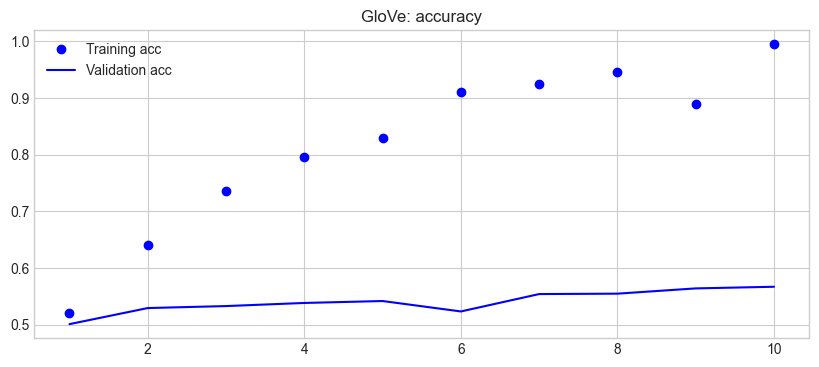

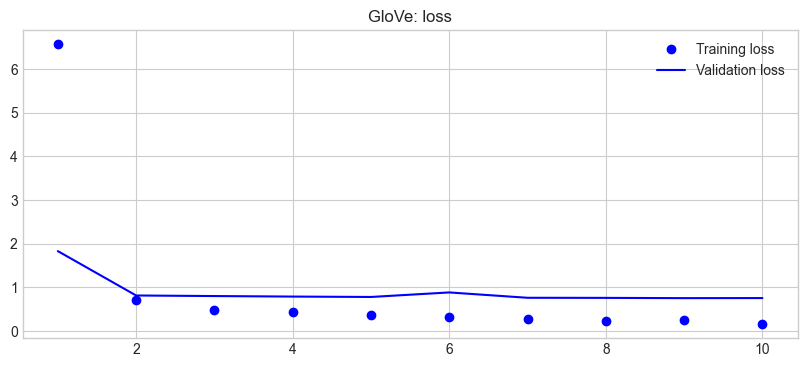

In [25]:
plot_training_history(history, "GloVe")


Модель быстро достигает состояния переобучения, что неудивительно при таком малом объеме обучающих данных. По этой причине оценка точности демонстрирует высокую изменчивость, но все же достигает уровня `50%`.

Имейте в виду, что ваши результаты могут несколько отличаться от представленных, поскольку при таком небольшом объеме обучающих данных результаты сильно зависят от того, какие именно `200` образцов попадут в обучающую выборку при случайном выборе. Если вы получили худший результат, чем мы, попробуйте ради эксперимента отобрать другой набор из `200` случайных образцов (в реальной жизни у вас не будет такой возможности).


Эту же модель можно обучить без загрузки предварительно обученных векторных представлений слов и без замораживания слоя `Embedding`. В этом случае будет обучено представление, узкоспециализированное для входного набора токенов. В такой ситуации обычно получается более мощное представление, чем предварительно обученное, если имеется большой объем обучающих данных. Но в нашем случае имеется всего `200` обучающих образцов. Тем не менее давайте попробуем проделать это.


## Обучение той же модели без использования уже обученных векторных представлений


In [26]:
model_without_glove = build_imdb_model(
    max_words=max_words,
    embedding_dim=embedding_dim,
    maxlen=maxlen,
)

model_without_glove.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_without_glove = model_without_glove.fit(
    prepared["x_train"],
    prepared["y_train"],
    epochs=10,
    batch_size=32,
    validation_data=(prepared["x_val"], prepared["y_val"]),
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - accuracy: 0.4650 - loss: 0.6902 - val_accuracy: 0.5206 - val_loss: 0.6950
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.9750 - loss: 0.5379 - val_accuracy: 0.5237 - val_loss: 0.7054
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.9800 - loss: 0.4183 - val_accuracy: 0.5271 - val_loss: 0.7065
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.9900 - loss: 0.2634 - val_accuracy: 0.5281 - val_loss: 0.7117
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 1.0000 - loss: 0.1477 - val_accuracy: 0.5315 - val_loss: 0.7206
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 1.0000 - loss: 0.0825 - val_accuracy: 0.5319 - val_loss: 0.7321
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 1.0000 - loss: 0.0492 - val_accuracy: 0.5305 - val_loss: 0.7450
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 1.0000 - loss: 0.0311 - val_accuracy: 0.5299 - val_loss:

Теперь выведем графики изменения качества модели

* Точность на этапах обучения и проверки без использования уже обученных векторных представлений слов
* Потери на этапах обучения и проверки без использования уже обученных векторных представлений слов


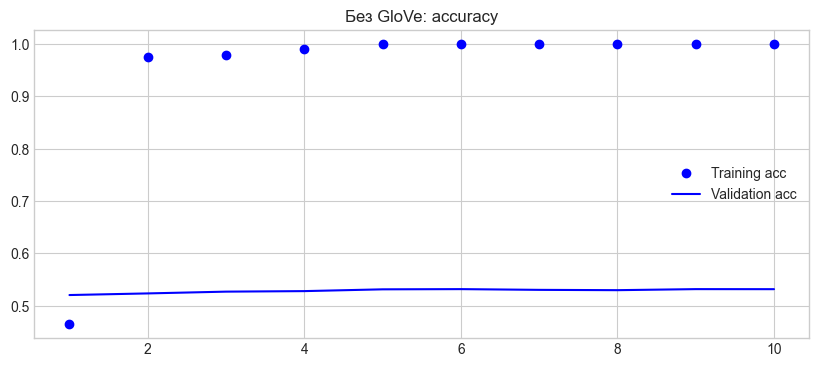

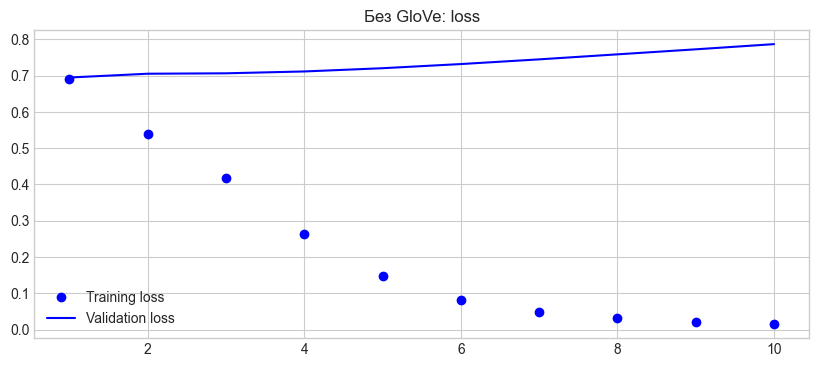

In [27]:
plot_training_history(history_without_glove, "Без GloVe")


Точность на этапе проверки замерла на уровне, близком к `50%`. То есть в данном случае предварительно обученные векторные представления слов выигрывают у вновь обученных. Если увеличить число обучающих образцов, ситуация быстро изменится на противоположную, — попробуйте ради эксперимента.


Наконец, оценим модель на контрольной выборке. Сначала токенизируем контрольные данные.


## Токенизация данных из контрольной выборки


In [28]:
test_texts, test_labels = load_imdb_split(imdb_dir / "test")

sequences = prepared["tokenizer"].texts_to_sequences(test_texts)
x_test = pad_sequences(sequences, maxlen=maxlen)
y_test = np.asarray(test_labels)

print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of x_test: (25000, 100)
Shape of y_test: (25000,)


А затем загрузим и оценим первую модель.


## Оценка модели на контрольном наборе данных


In [29]:
model.load_weights(pretrained_weights_path)
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_accuracy:.4f}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5628 - loss: 0.7613
Test accuracy: 0.5628


Мы получили удручающе низкую точность `56%`. Сложно добиться хорошего результата, имея лишь горстку обучающих образцов!


## Задание

Попробуйте увеличить обучающую выборку в самом начале и получить результаты классификации лучше чем `50%`.


In [30]:
assignment_training_samples = 2000

prepared_assignment = prepare_imdb_sequences(
    texts=train_texts,
    labels=train_labels,
    maxlen=maxlen,
    training_samples=assignment_training_samples,
    validation_samples=validation_samples,
    max_words=max_words,
)

assignment_embedding_matrix, assignment_found_words = build_embedding_matrix(
    word_index=prepared_assignment["word_index"],
    embeddings_index=embeddings_index,
    max_words=max_words,
    embedding_dim=embedding_dim,
)

print("Размер обучающей выборки:", prepared_assignment["x_train"].shape)
print("Размер проверочной выборки:", prepared_assignment["x_val"].shape)
print("Слов с найденными GloVe-векторами:", assignment_found_words)


Размер обучающей выборки: (2000, 100)
Размер проверочной выборки: (10000, 100)
Слов с найденными GloVe-векторами: 9800


In [31]:
assignment_model = build_imdb_model(
    max_words=max_words,
    embedding_dim=embedding_dim,
    maxlen=maxlen,
)

assignment_model.layers[0].set_weights([assignment_embedding_matrix])
assignment_model.layers[0].trainable = False

assignment_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

assignment_history = assignment_model.fit(
    prepared_assignment["x_train"],
    prepared_assignment["y_train"],
    epochs=10,
    batch_size=32,
    validation_data=(prepared_assignment["x_val"], prepared_assignment["y_val"]),
)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5610 - loss: 0.9949 - val_accuracy: 0.5389 - val_loss: 0.9946
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6665 - loss: 0.6520 - val_accuracy: 0.5733 - val_loss: 0.8628
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7265 - loss: 0.5273 - val_accuracy: 0.5926 - val_loss: 0.8381
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7865 - loss: 0.4484 - val_accuracy: 0.6303 - val_loss: 0.7268
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8360 - loss: 0.3601 - val_accuracy: 0.6344 - val_loss: 0.7492
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8880 - loss: 0.2882 - val_accuracy: 0.5712 - val_loss: 1.2283
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8815 - loss: 0.2640 - val_accuracy: 0.6389 - val_loss: 0.8034
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9180 - loss: 0.2082 - val_accuracy: 0.6327 - v

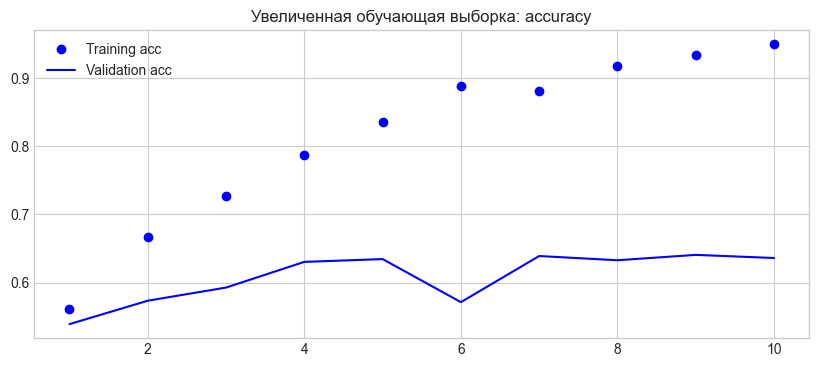

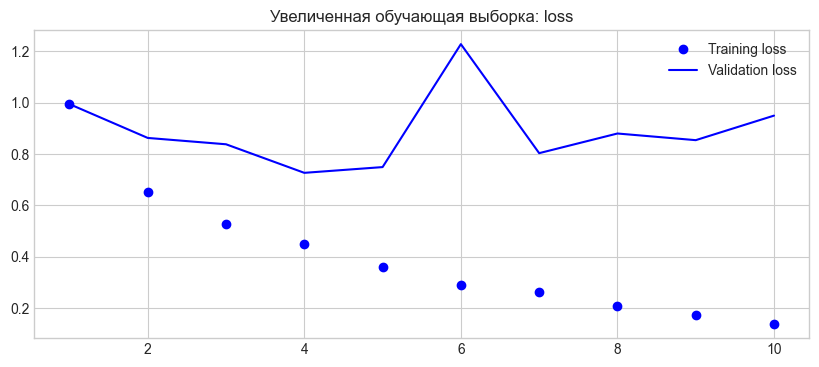

In [32]:
plot_training_history(assignment_history, "Увеличенная обучающая выборка")


In [33]:
assignment_test_sequences = prepared_assignment["tokenizer"].texts_to_sequences(test_texts)
x_test_assignment = pad_sequences(assignment_test_sequences, maxlen=maxlen)

assignment_test_loss, assignment_test_accuracy = assignment_model.evaluate(
    x_test_assignment,
    y_test,
)

print("Размер обучающей выборки:", assignment_training_samples)
print(f"Test accuracy: {assignment_test_accuracy:.4f}")
print(f"Лучше 50%: {assignment_test_accuracy > 0.5}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6386 - loss: 0.9643
Размер обучающей выборки: 2000
Test accuracy: 0.6386
Лучше 50%: True


## Вывод

В работе были последовательно рассмотрены прямое кодирование текста, хеширование признаков, обучаемые векторные представления слов и предварительно обученные эмбеддинги `GloVe`. На малой обучающей выборке модель быстро переобучается, поэтому итоговое качество нестабильно. Увеличение обучающей выборки дает модели больше размеченных примеров и позволяет получить результат классификации выше `50%`.
